In [ ]:
# Jika dijalankan di google colab (Jika download langsung dari github bisa skip)
!git clone https://github.com/MasAdiKun/emo-recog-simulation.git


Cloning into 'emo-recog-simulation'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 206 (delta 0), reused 206 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 313.83 KiB | 12.55 MiB/s, done.


# Import Required Library

In [ ]:
import os
import random
import shutil
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.applications import ResNet50V2

from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

import matplotlib.pyplot as plt

# Working with the Dataset

## Define the Dataset

In [ ]:
# Jika dijalankan di Google Colab
RAW_DATASET_DIR = "/content/emo-recog-simulation/sample_dataset"
#Jika di lokal hasil download/clone seluruh isi github (comment path sebelumnya)
# RAW_DATASET_DIR = "sample_dataset"

CLASS_NAMES = sorted([
    folder
    for folder in os.listdir(RAW_DATASET_DIR)
    if os.path.isdir(
        os.path.join(RAW_DATASET_DIR, folder)
    )
])

COUNT_CLASSES = len(CLASS_NAMES)


print("Classes:", CLASS_NAMES)
print("Total classes:", COUNT_CLASSES)

Classes: ['angry', 'happy']
Total classes: 2


## Split Dataset into Train, Val, and Test

In [ ]:
# Jika dijalankan di Google Colab
SPLIT_DIR = "/content/dataset_split"
#Jika di lokal hasil download/clone seluruh isi github (comment path sebelumnya)
# SPLIT_DIR = "dataset_split"
def split_dataset(
    source_dir,
    output_dir,
    train_ratio=0.7,
    val_ratio=0.2,
    seed=42
):
    random.seed(seed)
    for split in ["train","val","test"]:
        for cls in CLASS_NAMES:
            os.makedirs(
                os.path.join(output_dir, split, cls),
                exist_ok=True
            )

    for cls in CLASS_NAMES:
        class_dir = os.path.join(
            source_dir,
            cls
        )
        images = [
            img for img in os.listdir(class_dir)
            if img.lower().endswith(
                (".jpg",".png",".jpeg")
            )
        ]

        random.shuffle(images)
        train_end = int(
            len(images)*train_ratio
        )
        val_end = train_end + int(
            len(images)*val_ratio
        )

        split_data = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }
        for split, imgs in split_data.items():
            for img in imgs:
                shutil.copy2(
                    os.path.join(
                        class_dir,
                        img
                    ),
                    os.path.join(
                        output_dir,
                        split,
                        cls,
                        img
                    )
                )
        print(
            cls,
            {
                k:len(v)
                for k,v in split_data.items()
            }
        )

In [ ]:
split_dataset(
    RAW_DATASET_DIR,
    SPLIT_DIR
)

angry {'train': 70, 'val': 20, 'test': 10}
happy {'train': 70, 'val': 20, 'test': 10}


## Load Dataset for Preprocessing

In [ ]:
# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 10

In [ ]:
# Train Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names

Found 140 files belonging to 2 classes.
Found 40 files belonging to 2 classes.
Found 20 files belonging to 2 classes.


### Preprocessing

In [ ]:
# Mengubah skala warna ke 0 -> 1.0
normalization = tf.keras.layers.Rescaling(
    1./255
)
# Memperkaya variasi data untuk pelatihan
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    tf.keras.layers.RandomRotation(
        0.1
    ),
    tf.keras.layers.RandomZoom(
        0.1
    )
])

In [ ]:
# Preproc data training
train_ds = train_ds.map(
    lambda x, y: (
        augmentation(normalization(x)),
        y
    )
)
# Preproc data validation
val_ds = val_ds.map(
    lambda x, y: (
        normalization(x),
        y
    )
)
# Preproc data test
test_ds = test_ds.map(
    lambda x, y: (
        normalization(x),
        y
    )
)

### Optimasi sebelum pelatihan (Opsional)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

# Mengembangkan Model

## Define Arsitektur Model

In [ ]:
base_model = ResNet50V2(
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    include_top=False,
    weights="imagenet"
)

# freeze semua layer
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(2,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Melatih Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6000 - loss: 0.6714 - val_accuracy: 0.5750 - val_loss: 0.6857
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.7143 - loss: 0.5625 - val_accuracy: 0.6750 - val_loss: 0.5772
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.7000 - loss: 0.5795 - val_accuracy: 0.6250 - val_loss: 0.5983
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6357 - loss: 0.6131 - val_accuracy: 0.6750 - val_loss: 0.5616
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.7643 - loss: 0.5146 - val_accuracy: 0.6750 - val_loss: 0.6271


## Testing dari Model yang telah Dikembangkan

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(
    f"Test Accuracy: {test_accuracy:.2f}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6500 - loss: 0.5300
Test Accuracy: 0.65


# Use Model in RealTime

In [ ]:
def predict_image():
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]
    img = load_img(
        img_path,
        target_size=(224,224)
    )
    # Tampilkan gambar
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    # Convert ke array
    img_array = img_to_array(img)
    # Normalisasi sama seperti training
    img_array = img_array / 255.0
    # Tambahkan batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )
    # Prediksi
    prediction = model.predict(
        img_array
    )
    # Ambil probabilitas tertinggi
    predicted_index = np.argmax(
        prediction[0]
    )
    predicted_class = CLASS_NAMES[
        predicted_index
    ]
    confidence = np.max(
        prediction[0]
    )
    print(
        f"Prediction: {predicted_class}"
    )
    print(
        f"Confidence: {confidence:.2%}"
    )

Saving OIP (1).webp to OIP (1) (1).webp


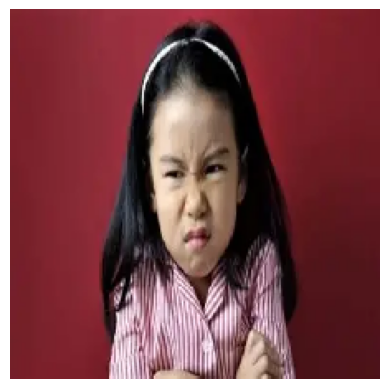

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Prediction: happy
Confidence: 65.68%


In [ ]:
predict_image()